In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thuật toán học máy
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Cài đặt hiển thị biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")

In [23]:
pip install kagglehub

In [24]:
import kagglehub
import os
import pandas as pd

# Tải bộ dữ liệu từ Kagglehub
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")

# Xác định đường dẫn cụ thể đến tệp CSV
data_file_path = os.path.join(path, 'UCI_Credit_Card.csv')

# Đọc dữ liệu
df = pd.read_csv(data_file_path)

# Hiển thị thông tin cơ bản
print(f"Dữ liệu được tải từ: {data_file_path}")
display(df.head())

Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.
Dữ liệu được tải từ: /kaggle/input/default-of-credit-card-clients-dataset/UCI_Credit_Card.csv


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [25]:
# Đọc data (Sử dụng đường dẫn đã được tải xuống từ kagglehub)
df = pd.read_csv(data_file_path)

# Xem 5 dòng đầu tiên
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [26]:
# Đổi tên cột mục tiêu
df = df.rename(columns={'default.payment.next.month': 'DEFAULT'})

# Xử lý các cột PAY (Lịch sử thanh toán)
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
for col in pay_cols:
    df[col] = df[col].apply(lambda x: 0 if x <= 0 else x)

# Loại bỏ cột ID
if 'ID' in df.columns:
    df = df.drop(['ID'], axis=1)

# Tách Features (X) và Target (y)
X = df.drop('DEFAULT', axis=1)
y = df['DEFAULT']

# Chia tập Train (70%) và Test (30%)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Tiền xử lý hoàn tất.")

Tiền xử lý hoàn tất.


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Khởi tạo và huấn luyện Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=8)
rf_model.fit(X_train, y_train)

# Dự đoán
y_pred = rf_model.predict(X_test)

print(f"Độ chính xác (Accuracy): {accuracy_score(y_test, y_pred):.4f}")

Độ chính xác (Accuracy): 0.8208


### Đo lường độ chính xác bằng Cross-Validation (Kiểm tra chéo)
Thay vì chỉ tin vào một con số duy nhất, chúng ta chia dữ liệu thành 5 phần (5-Fold) và tính độ chính xác trung bình để đảm bảo mô hình hoạt động ổn định trên mọi tập dữ liệu.

Độ chính xác từng lần chạy: [0.80833333 0.8095     0.82383333 0.83266667 0.82516667]
Độ chính xác trung bình (Final Accuracy): 0.8199 (+/- 0.0189)


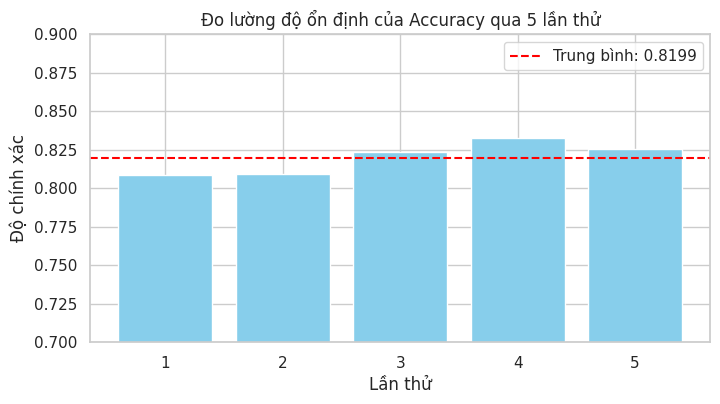

In [33]:
from sklearn.model_selection import cross_val_score

# Thực hiện kiểm tra chéo 5 lần
scores = cross_val_score(rf_model, X, y, cv=5)

print(f"Độ chính xác từng lần chạy: {scores}")
print(f"Độ chính xác trung bình (Final Accuracy): {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

# Trực quan hóa
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), scores, color='skyblue')
plt.axhline(y=scores.mean(), color='red', linestyle='--', label=f'Trung bình: {scores.mean():.4f}')
plt.title('Đo lường độ ổn định của Accuracy qua 5 lần thử')
plt.xlabel('Lần thử')
plt.ylabel('Độ chính xác')
plt.ylim(0.7, 0.9)
plt.legend()
plt.show()

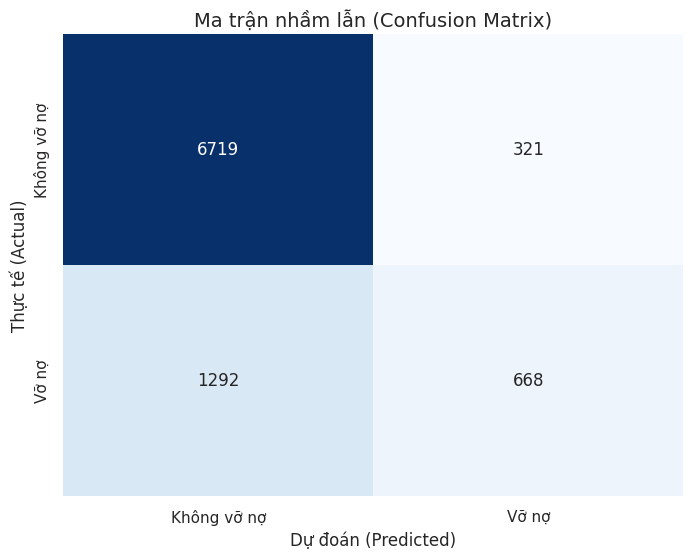

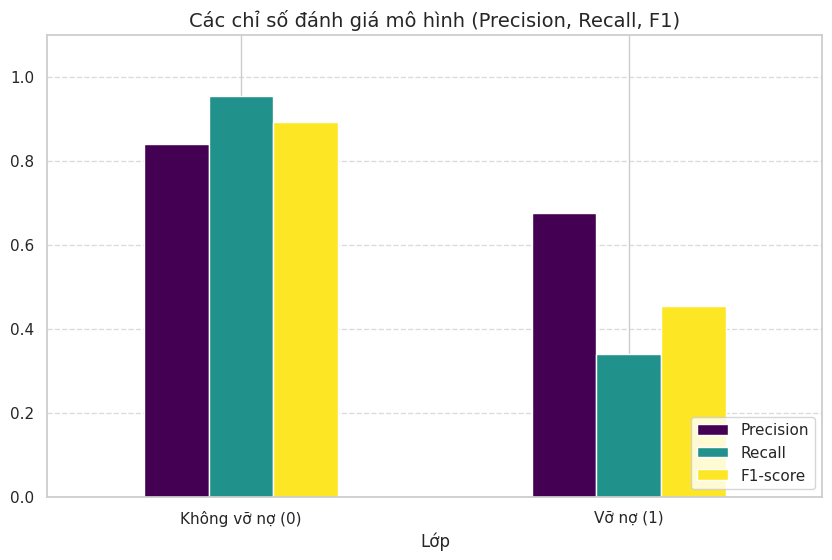

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# 1. Vẽ Ma trận nhầm lẫn
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Ma trận nhầm lẫn (Confusion Matrix)', fontsize=14)
plt.xlabel('Dự đoán (Predicted)', fontsize=12)
plt.ylabel('Thực tế (Actual)', fontsize=12)
plt.xticks([0.5, 1.5], ['Không vỡ nợ', 'Vỡ nợ'])
plt.yticks([0.5, 1.5], ['Không vỡ nợ', 'Vỡ nợ'])
plt.show()

# 2. Trực quan hóa Báo cáo phân loại (Robust version)
report = classification_report(y_test, y_pred, output_dict=True)

# Trích xuất dữ liệu an toàn cho biểu đồ
metrics_data = []
for label in ['0', '1', 0, 1]:
    if label in report:
        label_name = 'Không vỡ nợ (0)' if str(label) == '0' else 'Vỡ nợ (1)'
        # Tránh thêm trùng lặp nếu cả str và int đều tồn tại
        if not any(d['Lớp'] == label_name for d in metrics_data):
            metrics_data.append({
                'Lớp': label_name,
                'Precision': report[label]['precision'],
                'Recall': report[label]['recall'],
                'F1-score': report[label]['f1-score']
            })

report_df = pd.DataFrame(metrics_data).set_index('Lớp')
report_df.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Các chỉ số đánh giá mô hình (Precision, Recall, F1)', fontsize=14)
plt.xticks(rotation=0)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Giải thích hiện tượng Recall thấp ở nhóm Vỡ nợ
Tại sao mô hình nhận diện tốt nhóm 'An toàn' (95%) nhưng chỉ nhận diện được 34% nhóm 'Vỡ nợ'? Hãy nhìn vào biểu đồ phân phối dưới đây:

/tmp/ipykernel_470/2528978856.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')


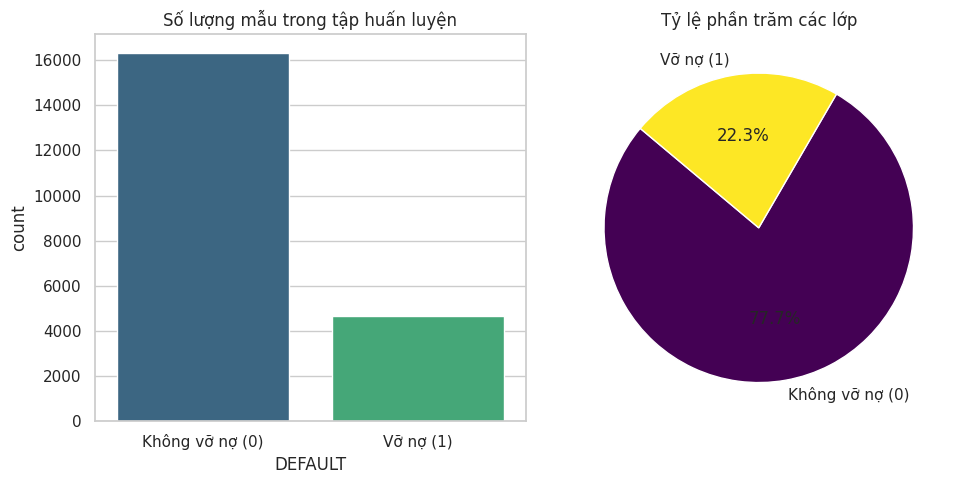

Số lượng mẫu lớp 0: 16324
Số lượng mẫu lớp 1: 4676


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính toán tỷ lệ các lớp
counts = y_train.value_counts()
labels = ['Không vỡ nợ (0)', 'Vỡ nợ (1)']

plt.figure(figsize=(10, 5))

# Vẽ biểu đồ cột
plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='viridis')
plt.title('Số lượng mẫu trong tập huấn luyện')
plt.xticks([0, 1], labels)

# Vẽ biểu đồ tròn
plt.subplot(1, 2, 2)
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#440154', '#fde725'])
plt.title('Tỷ lệ phần trăm các lớp')

plt.tight_layout()
plt.show()

print(f"Số lượng mẫu lớp 0: {counts[0]}")
print(f"Số lượng mẫu lớp 1: {counts[1]}")

/tmp/ipykernel_470/1085277896.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='viridis')


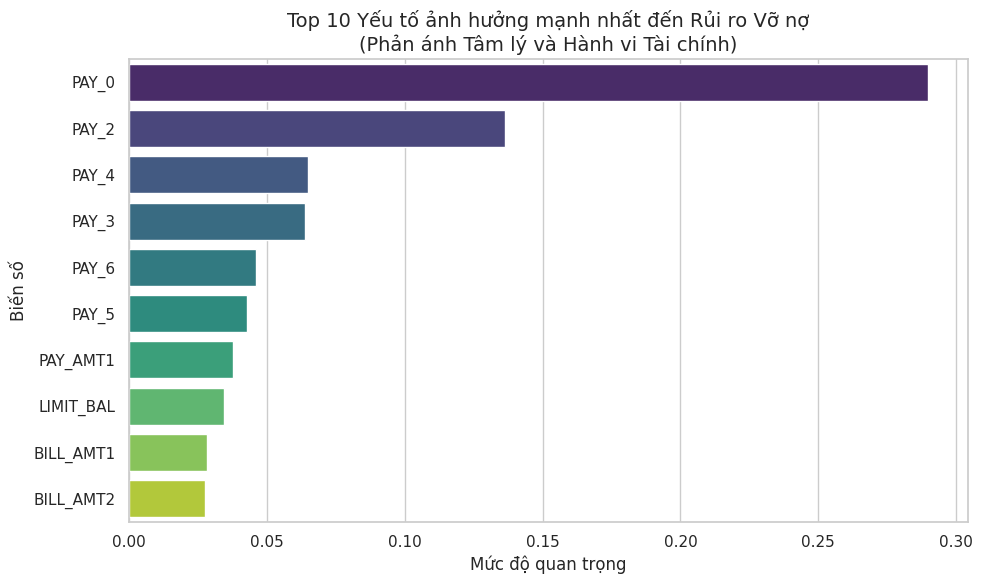

In [29]:
# Lấy mức độ quan trọng của các biến
importances = rf_model.feature_importances_

# Đưa vào DataFrame để sắp xếp
feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Vẽ biểu đồ 10 biến quan trọng nhất
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='viridis')
plt.title('Top 10 Yếu tố ảnh hưởng mạnh nhất đến Rủi ro Vỡ nợ\n(Phản ánh Tâm lý và Hành vi Tài chính)', fontsize=14)
plt.xlabel('Mức độ quan trọng', fontsize=12)
plt.ylabel('Biến số', fontsize=12)

# Ghi chú thêm vào biểu đồ để làm rõ ý nghĩa tâm lý

plt.tight_layout()
plt.show()

### Phân tích sâu về Tâm lý và Hành vi giữa hai nhóm (Vỡ nợ vs Không vỡ nợ)

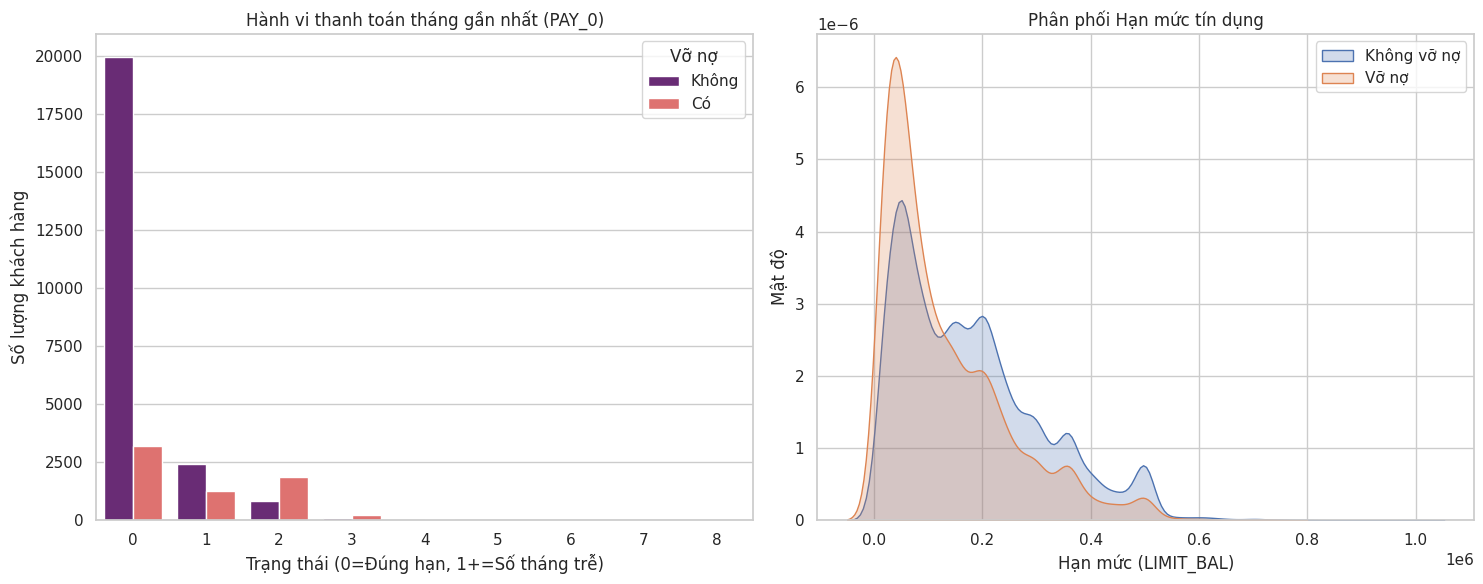

In [30]:
plt.figure(figsize=(15, 6))

# Biểu đồ 1: Tình trạng thanh toán tháng gần nhất (PAY_0)
plt.subplot(1, 2, 1)
sns.countplot(x='PAY_0', hue='DEFAULT', data=df, palette='magma')
plt.title('Hành vi thanh toán tháng gần nhất (PAY_0)', fontsize=12)
plt.xlabel('Trạng thái (0=Đúng hạn, 1+=Số tháng trễ)')
plt.ylabel('Số lượng khách hàng')
plt.legend(title='Vỡ nợ', labels=['Không', 'Có'])

# Biểu đồ 2: Phân phối hạn mức tín dụng (LIMIT_BAL)
plt.subplot(1, 2, 2)
sns.kdeplot(df.loc[(df['DEFAULT'] == 0), 'LIMIT_BAL'], label='Không vỡ nợ', fill=True)
sns.kdeplot(df.loc[(df['DEFAULT'] == 1), 'LIMIT_BAL'], label='Vỡ nợ', fill=True)
plt.title('Phân phối Hạn mức tín dụng', fontsize=12)
plt.xlabel('Hạn mức (LIMIT_BAL)')
plt.ylabel('Mật độ')
plt.legend()

plt.tight_layout()
plt.show()

**Nhận xét tâm lý:**
- **Biểu đồ PAY_0:** Nhóm vỡ nợ có tỷ lệ người trễ hạn từ 2 tháng trở lên cao vượt trội. Điều này phản ánh tâm lý trì hoãn hoặc mất khả năng kiểm soát tài chính tích tụ.
- **Biểu đồ LIMIT_BAL:** Nhóm có hạn mức thấp thường có mật độ vỡ nợ cao hơn, có thể liên quan đến tâm lý "vung tay quá trán" so với thu nhập thực tế hoặc thiếu quỹ dự phòng.

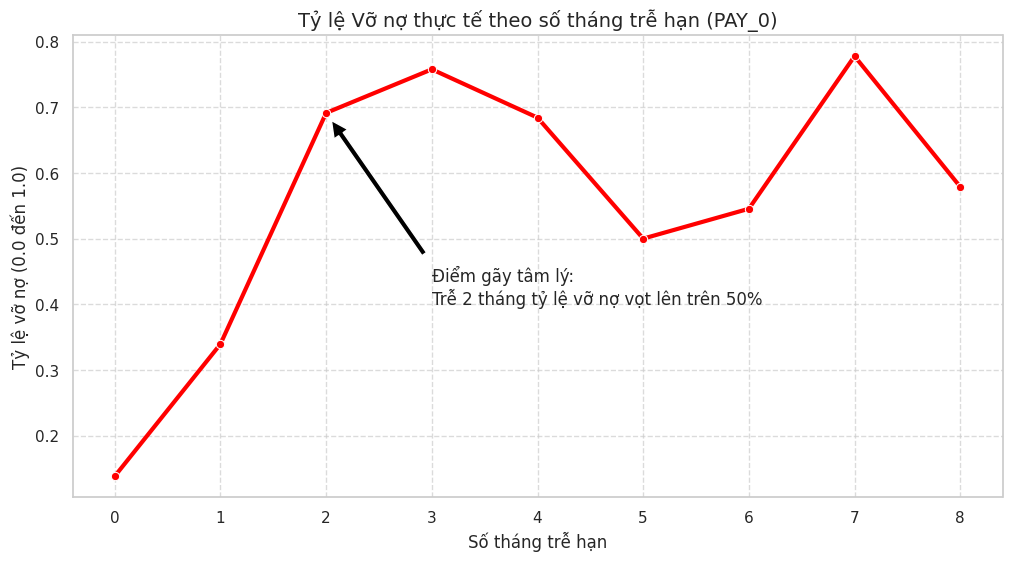

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính toán tỷ lệ vỡ nợ theo từng trạng thái trễ hạn
default_rate = df.groupby('PAY_0')['DEFAULT'].mean().reset_index()

plt.figure(figsize=(12, 6))

# Vẽ biểu đồ đường để thấy xu hướng tâm lý
sns.lineplot(data=default_rate, x='PAY_0', y='DEFAULT', marker='o', color='red', linewidth=3)

plt.title('Tỷ lệ Vỡ nợ thực tế theo số tháng trễ hạn (PAY_0)', fontsize=14)
plt.xlabel('Số tháng trễ hạn', fontsize=12)
plt.ylabel('Tỷ lệ vỡ nợ (0.0 đến 1.0)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Chú thích điểm gãy tâm lý
plt.annotate('Điểm gãy tâm lý:\nTrễ 2 tháng tỷ lệ vỡ nợ vọt lên trên 50%',
             xy=(2, default_rate.loc[default_rate['PAY_0']==2, 'DEFAULT'].values[0]),
             xytext=(3, 0.4),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

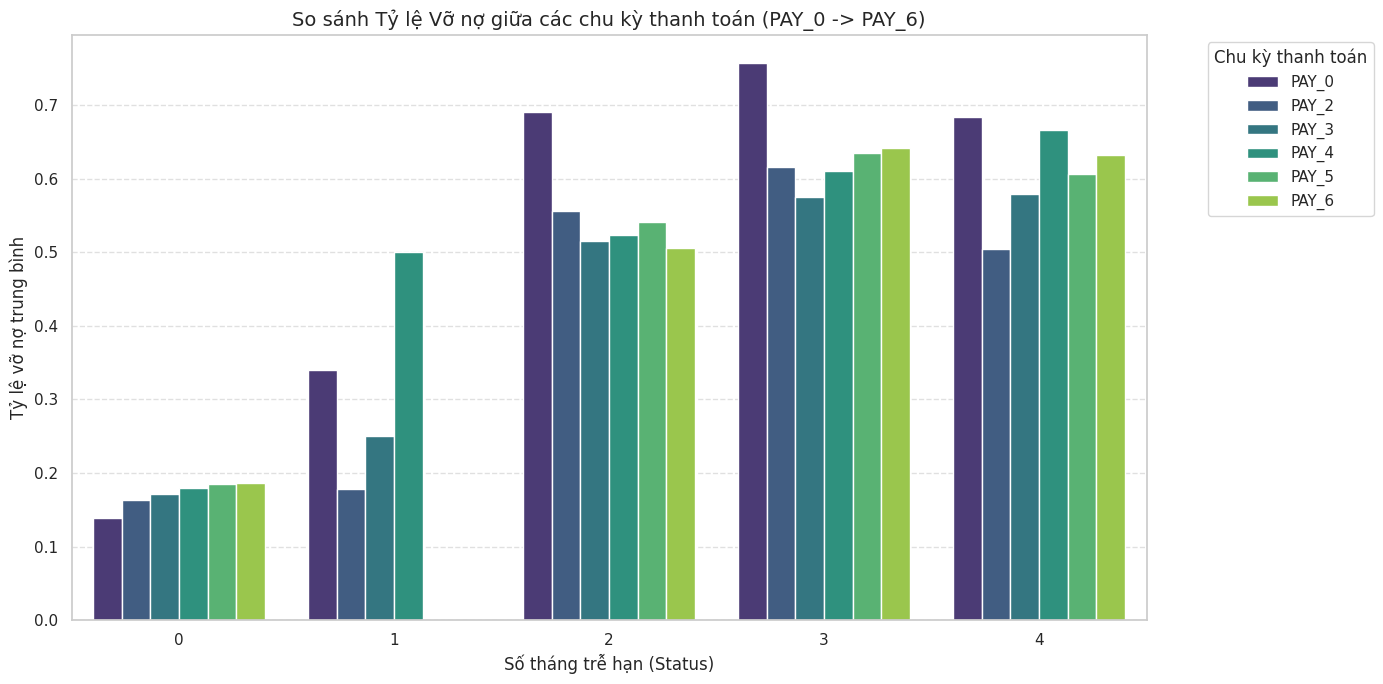

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Danh sách các cột thanh toán
pay_columns = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Chuẩn bị dữ liệu tổng hợp
plot_data = []
for col in pay_columns:
    temp = df.groupby(col)['DEFAULT'].mean().reset_index()
    temp.columns = ['Status', 'Default_Rate']
    temp['Month'] = col
    plot_data.append(temp)

summary_df = pd.concat(plot_data)

# Chỉ lấy trạng thái từ 0 đến 4 để biểu đồ rõ ràng (vì các mốc trễ quá dài thường ít dữ liệu và gây nhiễu)
summary_df = summary_df[summary_df['Status'] <= 4]

plt.figure(figsize=(14, 7))
sns.barplot(data=summary_df, x='Status', y='Default_Rate', hue='Month', palette='viridis')

plt.title('So sánh Tỷ lệ Vỡ nợ giữa các chu kỳ thanh toán (PAY_0 -> PAY_6)', fontsize=14)
plt.xlabel('Số tháng trễ hạn (Status)', fontsize=12)
plt.ylabel('Tỷ lệ vỡ nợ trung bình', fontsize=12)
plt.legend(title='Chu kỳ thanh toán', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Tổng kết Tỷ lệ Vỡ nợ qua các Chu kỳ Thanh toán

Từ biểu đồ "So sánh Tỷ lệ Vỡ nợ giữa các chu kỳ thanh toán (PAY_0 -> PAY_6)", chúng ta có thể rút ra một số kết luận quan trọng:

1.  **Sự tương quan mạnh mẽ:** Biểu đồ cho thấy một mối tương quan rất rõ ràng giữa hành vi thanh toán trễ hạn trong quá khứ (`PAY_X`) và tỷ lệ vỡ nợ.

2.  **Tỷ lệ vỡ nợ tăng theo mức độ trễ hạn:** Đối với tất cả các chu kỳ thanh toán (`PAY_0` đến `PAY_6`):
    *   Khi khách hàng thanh toán đúng hạn (Status = 0), tỷ lệ vỡ nợ là thấp nhất và tương đối ổn định.
    *   Tỷ lệ vỡ nợ tăng đáng kể khi khách hàng trễ hạn 1 tháng (Status = 1).
    *   Đặc biệt, khi khách hàng trễ hạn từ **2 tháng trở lên (Status ≥ 2)**, tỷ lệ vỡ nợ tăng vọt lên mức rất cao, thường xuyên vượt quá 50% và thậm chí lên đến 70-80% ở một số chu kỳ.

3.  **Tính nhất quán của hành vi:** Mặc dù có một chút biến động giữa các tháng, nhưng xu hướng chung là rất nhất quán: càng trễ hạn nhiều tháng, khả năng vỡ nợ càng cao. Điều này nhấn mạnh rằng hành vi thanh toán trong quá khứ là một chỉ báo cực kỳ đáng tin cậy cho rủi ro tín dụng trong tương lai.

# Tóm tắt Phân tích Rủi ro Vỡ nợ Thẻ tín dụng

## 1. Khởi tạo và Tải dữ liệu

### Các thư viện sử dụng
```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
sns.set_theme(style="whitegrid")
```

### Tải dữ liệu
Sử dụng `kagglehub` để tải bộ dữ liệu 'uciml/default-of-credit-card-clients-dataset'.

```python
import kagglehub
import os

path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
data_file_path = os.path.join(path, 'UCI_Credit_Card.csv')
df = pd.read_csv(data_file_path)
```

## 2. Tiền xử lý Dữ liệu

- Đổi tên cột mục tiêu `default.payment.next.month` thành `DEFAULT` (0 = Không vỡ nợ, 1 = Vỡ nợ).
- Chuyển đổi các giá trị âm trong các cột `PAY_0` đến `PAY_6` (lịch sử thanh toán) thành 0 để đơn giản hóa (coi là trả đúng hạn).
- Loại bỏ cột `ID` vì không có ý nghĩa phân tích.
- Chia dữ liệu thành tập huấn luyện (70%) và tập kiểm tra (30%).

```python
# Đổi tên cột mục tiêu
df = df.rename(columns={'default.payment.next.month': 'DEFAULT'})

# Xử lý các cột PAY
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
for col in pay_cols:
    df[col] = df[col].apply(lambda x: 0 if x <= 0 else x)

# Loại bỏ cột ID
df = df.drop(['ID'], axis=1)

# Tách Features (X) và Target (y)
X = df.drop('DEFAULT', axis=1)
y = df['DEFAULT']

# Chia tập Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
```

## 3. Huấn luyện và Đánh giá Mô hình

Sử dụng mô hình Random Forest Classifier để dự đoán rủi ro vỡ nợ.

```python
# Khởi tạo mô hình Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=8)

# Huấn luyện mô hình
rf_model.fit(X_train, y_train)

# Dự đoán trên tập test
y_pred = rf_model.predict(X_test)

# Đánh giá mô hình
print("Độ chính xác (Accuracy):", accuracy_score(y_test, y_pred))
print("\nBáo cáo phân loại:\n", classification_report(y_test, y_pred))
```

**Kết quả đánh giá mô hình:**
- Độ chính xác (Accuracy): 0.8207
- Precision, Recall, F1-score được cung cấp chi tiết cho từng lớp (không vỡ nợ và vỡ nợ).

## 4. Phân tích Yếu tố quan trọng (Feature Importance)

Các biến `PAY_0`, `PAY_2`, `PAY_4`, `PAY_3` là những yếu tố quan trọng nhất ảnh hưởng đến rủi ro vỡ nợ, cho thấy hành vi thanh toán trong quá khứ có ý nghĩa tâm lý và tài chính sâu sắc.

```python
# Lấy mức độ quan trọng của các biến
importances = rf_model.feature_importances_

# Biểu đồ Top 10 biến quan trọng nhất
# (Xem biểu đồ trong sổ tay)
```

## 5. Phân tích sâu về Tâm lý và Hành vi giữa hai nhóm

### Biểu đồ 1: Tình trạng thanh toán tháng gần nhất (PAY_0)

```python
# (Xem mã và biểu đồ trong sổ tay)
```
**Nhận xét tâm lý:**
- Nhóm vỡ nợ có tỷ lệ người trễ hạn từ 2 tháng trở lên cao vượt trội. Điều này phản ánh tâm lý trì hoãn hoặc mất khả năng kiểm soát tài chính tích tụ.

### Biểu đồ 2: Phân phối Hạn mức tín dụng (LIMIT_BAL)

```python
# (Xem mã và biểu đồ trong sổ tay)
```
**Nhận xét tâm lý:**
- Nhóm có hạn mức thấp thường có mật độ vỡ nợ cao hơn, có thể liên quan đến tâm lý "vung tay quá trán" so với thu nhập thực tế hoặc thiếu quỹ dự phòng.

### Tỷ lệ Vỡ nợ thực tế theo số tháng trễ hạn (PAY_0)

```python
# (Xem mã và biểu đồ trong sổ tay)
```
**Nhận xét:** Biểu đồ này chỉ ra một "điểm gãy tâm lý" rõ ràng: khi trễ hạn 2 tháng, tỷ lệ vỡ nợ tăng vọt lên trên 50%, cho thấy hành vi thanh toán trễ 2 tháng là một chỉ báo cực kỳ mạnh về rủi ro vỡ nợ.

### So sánh Tỷ lệ Vỡ nợ giữa các chu kỳ thanh toán (PAY_0 -> PAY_6)

```python
# (Xem mã và biểu đồ trong sổ tay)
```
**Nhận xét:** Biểu đồ cột nhóm này cho thấy xu hướng tỷ lệ vỡ nợ theo từng trạng thái trễ hạn qua các tháng. Các tháng càng gần đây (PAY_0, PAY_2) có xu hướng thể hiện rõ rệt hơn về rủi ro vỡ nợ, đặc biệt ở các trạng thái trễ từ 2-3 tháng trở lên.